## Use this notebook to calculate bolometric corrections for the U, B and V bands in the Johnson-Cousins photometric system for 4 main-sequence (MS, luminosity class V) stars of spectral classes between B0V and M0V (masses between 17 $M_\odot$ and 0.6 $M_\odot$) using their Kurucz theoretical spectra

Take the Kurucz theoretical spectra from the left column (with the title **Kurucz ODFNEW/NOVER models**) of the list at http://svo2.cab.inta-csic.es/theory/newov/index.php, and parameters $({\cal M}/{\cal M}_\odot,$ $R/R_\odot$ and $\log_{10}\,L/L_\odot)$ of MS stars (V dwarfs) either from internet, e.g. from http://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt, or as explained in the description of the homework assignment below. 

Assume that [Fe/H]=$0$ for all MS stars, except for Vega that has [Fe/H]=$-0.5$, $T_\mathrm{eff}=9550$ K, $\log_{10}g=3.95$ (cm/s$^2$) and $(R/d)^2=6.247\times 10^{-17}$.

The Bessell UBVRI response functions similar to the ones from http://spiff.rit.edu/classes/phys440/lectures/filters/filters.html are already available for these calculations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# physical constants
import scipy.constants as sc

# astronomical constants
from astropy import constants as ac

from scipy.integrate import simpson
from scipy import interpolate

fsize=16
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'

In [2]:
# minimum and maximum wave lengths in Angstroms used in plots
wl_min = 3000. 
wl_max = 10000. 

A bolometric correction in a photometric band A is

$$
BC_\mathrm{A} = 4.75 - 2.5\log_{10}\left[\frac{4\pi (10\mathrm{pc})^2\sigma T_\mathrm{eff}^4}{L_\odot}\right]
+ 2.5\log_{10}\left[\frac{\int_{\lambda_1}^{\lambda_2} F_\lambda S_\lambda d\lambda}{\int_{\lambda_1}^{\lambda_2} f^{0}_{\lambda} S_\lambda d\lambda}\right] - m^0_\mathrm{A},
$$

where $S_\lambda$ is a photometric-band response function, $F_\lambda$ is the intrinsic (at its surface) monochromatic flux from the star, $f^{0}_\lambda$ is the flux from a standard star (Vega) measured at the top of Earth's atmosphere and $m^{0}_\mathrm{A}$ is its apparent magnitude (zero for Vega).  

Therefore, we have to first calculate $\int_{\lambda_1}^{\lambda_2} f^{0}_{\lambda} S_\lambda d\lambda$
for Vega. A value of this integral will be assigned to res_0.

# Execute the following cells without changing anything, except your choice of a photometric band, until the section where your work begins

### In the following cells, the flux from Vega is calculated within a chosen photometric band that is later used to normalize a bolometric correction for your selected MS star.

In [3]:
# first, read in a Kurucz theoretical spectrum of a star that is as similar to Vega
# as possible from http://svo2.cab.inta-csic.es/theory/newov/index.php

star = 'Vega' # almost, with the closest parameters
Teff = 9500 # K

# parameters of the star (Vega is an A0V star), 
# e.g. from http://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt
M = 2.18
R = 2.19
lgM = np.log10(M) 
lgR = np.log10(R) 
lgL = 1.57

#print ac.M_sun, ac.R_sun, ac.L_sun
g = sc.G*(10.**lgM*ac.M_sun)/(10.**lgR*ac.R_sun)**2 

# Note that in expressions one should use g.value, ac.L_sun.value, etc.

print ("g =", g, "and its value in SI is",g.value)
lgg = np.log10(1e2*g.value) # 1e2 transforms m/s**2 to cm/s**2, as used in model atmospheres
print ("lgg =", lgg, "(cm/s**2)") # for MS stars lgg should be around 4.
Teff = ((ac.L_sun.value/ac.R_sun.value**2)*10.**lgL/(4*sc.pi*(10.**lgR)**2*sc.sigma))**0.25
print ("Teff =", Teff, "(K)")

#lgg = 4.0 # cm/s**2
# [Fe/H] = -0.5
Rd2 = 6.247e-17 # the square of the radius to distance ratio for Vega

mA0 = 0. # for Vega in the Johnson-Cousins system

# these are the names of the directory and file with theoretical stellar spectra
file_theory = open('./data/spectra/'+star+'theoryspectrum.txt',"r")

wl_theory = []
fl_theory = []

for line in file_theory:
    data = line.split()
    wl_theory.append(float(data[0]))
    fl_theory.append(float(data[1]))

file_theory.close()

# normalize the flux
fl_max = max(fl_theory)  # this parameter will be used later

n_theory = len(wl_theory)
for i in range(n_theory):
    fl_theory[i] = fl_theory[i]/fl_max

g = 124.63381568630211 kg / m2 and its value in SI is 124.63381568630211
lgg = 4.095635891227501 (cm/s**2)
Teff = 9629.517417040588 (K)


### now, read in the UBVRI response functions that can be downloaded from http://www.aip.de/en/research/facilities/stella/instruments/data/johnson-ubvri-filter-curves

In [4]:
# now, read in the UBVRI response functions that can be downloaded 
# from http://www.aip.de/en/research/facilities/stella/instruments/data/johnson-ubvri-filter-curves

band = ['U', 'B', 'V', 'R', 'I']
col = ['c', 'b', 'y', 'r', 'm']
n_band = len(band)

wl_band = []
sl_band = []

for k in range(n_band):
    
    wl_band.append([])
    sl_band.append([])
    # these are the names of the directory and file with the response functions   
    file_band = open('./data/spectra/Bessel_'+band[k]+'-1.txt',"r")


    for line in file_band:
        data = line.split()
        wl_band[k].append(10.*float(data[0])) # multiplied by 10 to transform nm to A
        sl_band[k].append(float(data[1]))

    file_band.close()
    
    # reverse the band arrays, so that wl_band increases along with wl_theory
    wl_band[k][:] = wl_band[k][::-1]
    sl_band[k][:] = sl_band[k][::-1]

    # normalize response functions
    sl_max = max(sl_band[k][:])
    for i in range(len(sl_band[k][:])):
        sl_band[k][i] = sl_band[k][i]/sl_max

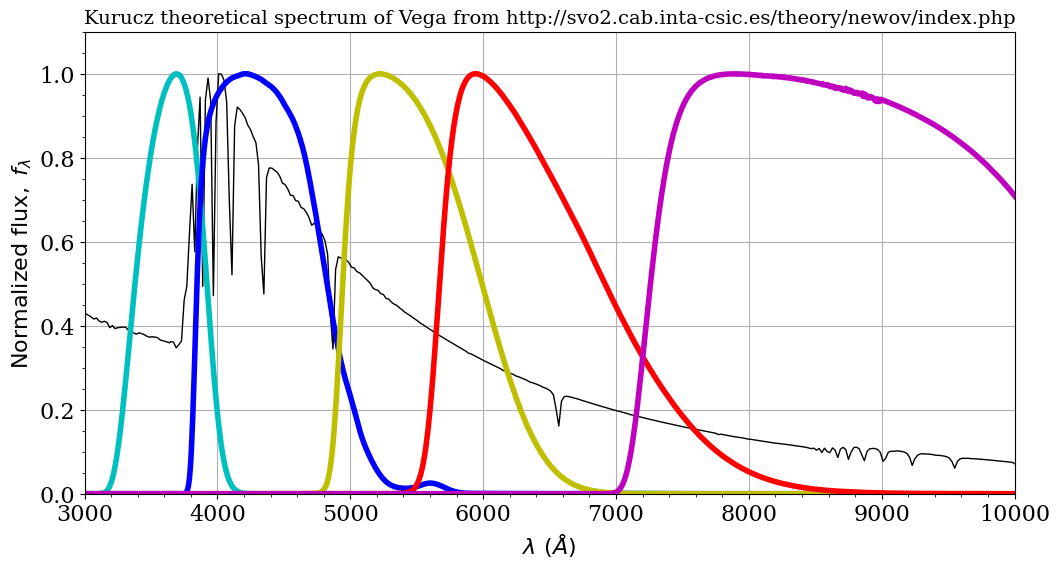

In [5]:
# plot the theoretical spectrum of Vega and response functions
fig=plt.figure()
ax=fig.gca()
fig.set_size_inches(12,6)

plt.plot(wl_theory,fl_theory,'k-',linewidth=1)    

for k in range(n_band):
    plt.plot(wl_band[k][:],sl_band[k][:],col[k],linewidth=4)

plt.xlim(wl_min,wl_max)
plt.ylim(0.,1.1)
plt.xlabel(r'$\lambda\ (\AA)$',fontsize=fsize)
plt.ylabel(r'$\mathrm{Normalized\ flux},\ f_\lambda$',fontsize=fsize)
plt.title('Kurucz theoretical spectrum of '+star+\
          ' from http://svo2.cab.inta-csic.es/theory/newov/index.php',fontsize=14)
plt.grid()
plt.minorticks_on()
#plt.tight_layout()
plt.show()

## This is where you have to select a photometric band for which the bolometric correction will be calculated

In [6]:
for kk in range(n_band):
    print ("k =", kk, "for band", band[kk])
    
k=2 # this is your selection
band_sel = band[k]
print ("The photometric band", band[k], "is selected")

k = 0 for band U
k = 1 for band B
k = 2 for band V
k = 3 for band R
k = 4 for band I
The photometric band V is selected


In [7]:
# isolate a range of wavelengths in which the selected response function is larger than sl_min
sl_min = 1e-4
wl_int = []
sl_int = []
for i in range(len(wl_band[k][:])):
    if sl_band[k][i] >= sl_min:
        wl_int.append(wl_band[k][i])
        sl_int.append(sl_band[k][i])
n_int = len(wl_int)

In [8]:
# select a part of the theoretical spectrum that overlaps with the isolated wavelength range
fl_int = []
x_int = []
wl_int_min = min(wl_int)
wl_int_max = max(wl_int)
for i in range(n_theory):
    if wl_theory[i] >= wl_int_min and wl_theory[i] <= wl_int_max:
        x_int.append(wl_theory[i])
        fl_int.append(fl_theory[i])
        
n_fl_int = len(x_int)
print (n_int, n_fl_int)
print ("lambda_1 =", wl_int[0], ", lambda_2 =", wl_int[-1])

523 131
lambda_1 = 4670.0 , lambda_2 = 7285.0


In [9]:
# prepare to interpolate the response function at the points in which the theoretical flux is provided
sl = interpolate.interp1d(wl_int,sl_int)

# this is the integrand that represents the convolution of the flux and response function
f_int = np.linspace(0,0,n_fl_int)
for i in range(n_fl_int):
    f_int[i] = fl_int[i]*sl(x_int[i])

# Simpson's rule is used here for integration
# after the integration don't forget to multiply by the flux normalization factor 
# fl_max that was found earlier
res = fl_max*simpson(f_int, x=x_int)
res_0 = res*Rd2 # this is the integral in the denominator in the above expression for BC_A

In [10]:
# calculate BC for Vega and compare it with the value from the internet table
BC = 4.75-2.5*np.log10(4*sc.pi*(10*ac.pc.value)**2*ac.sigma_sb.value*Teff**4/ac.L_sun.value)+\
2.5*np.log10(res/res_0)-mA0

BC_Vega = BC

print ("For the star", star, "the bolometric correction in the band", band_sel, "is", BC)

For the star Vega the bolometric correction in the band V is -0.19660090002221864


# This is where your work begins

### Select 4 masses between 17 $M_\odot$ and 0.6 $M_\odot$ for MS stars and use the cells below to calculate bolometric corrections for these stars in the bands U, B and V. Don't forget to repeat the above calculations for Vega when you change the photometric band.

For a selected mass $M$, estimate its corresponding MS luminosity and radius using the mass-luminosity relationship plotted in a slide of the A404 Introduction notebook and the fillowing mass-radius relationship:

$$
R\propto M^{0.8}
$$
for stars near or below solar mass, and

$$
R\propto M^{0.6}
$$
for more massive stars.

The gravitational acceleration at the surface of the star is

$$
g = \frac{GM}{R^2},
$$

and its effective temperature can be found from the relation

$$
L = 4\pi R^2\sigma T_\mathrm{eff}^4.
$$

### NOTE: delete all header and comment lines in your saved text files with Kurucz spectra. The read operators below assume that these files contain only numerical data with two columns with wavelength and flux!!!

### Also, pay attention to my naming of the spectra files and to the name of the directory in which they are saved. Change these, if you wish!

In [11]:
# first, read in a Kurucz theoretical spectrum of a star that is as similar to your selected MS star
# as possible from http://svo2.cab.inta-csic.es/theory/newov/index.php

# provide here parameters of the star
star = 'K2V' # 'K4V' # 'K5V' # its spectral class
print ("A", star, "star")

# parameters of the star estimated as explained in the cell above

M = 0.82 # 0.73 # 0.70
R = 0.783 # 0.713 # 0.701
Teff = 5100 # 4600. # 4440.
lgM = np.log10(M) 
lgR = np.log10(R) 
lgL = -0.43 # -0.69 # -0.76

#print ac.M_sun, ac.R_sun, ac.L_sun
g = sc.G*(10.**lgM*ac.M_sun)/(10.**lgR*ac.R_sun)**2 

# Note that in expressions one should use g.value, ac.L_sun.value, etc.

print ("g =", g, "and its value in SI is",g.value)
lgg = np.log10(1e2*g.value) # 1e2 transforms m/s**2 to cm/s**2, as used in model atmospheres
print ("lgg =", lgg, "(cm/s**2)") # for MS stars lgg should be around 4.
Teff = ((ac.L_sun.value/ac.R_sun.value**2)*10.**lgL/(4*sc.pi*(10.**lgR)**2*sc.sigma))**0.25
print ("Teff =", Teff, "(K)")

A K2V star
g = 366.7397254869129 kg / m2 and its value in SI is 366.7397254869129
lgg = 4.564357955570963 (cm/s**2)
Teff = 5092.671925149756 (K)


In [12]:
# read in a theoretical spectrum of the star
# take the Kurucz spectrum for the above specified parameters
# from http://svo2.cab.inta-csic.es/theory/newov/index.php

file_theory = open('./data/spectra/'+star+'theoryspectrum.txt',"r")

wl_theory = []
fl_theory = []

for line in file_theory:
    data = line.split()
    wl_theory.append(float(data[0]))
    fl_theory.append(float(data[1]))

file_theory.close()

# normalize the flux
fl_max = max(fl_theory)
n_theory = len(wl_theory)
for i in range(n_theory):
    fl_theory[i] = fl_theory[i]/fl_max

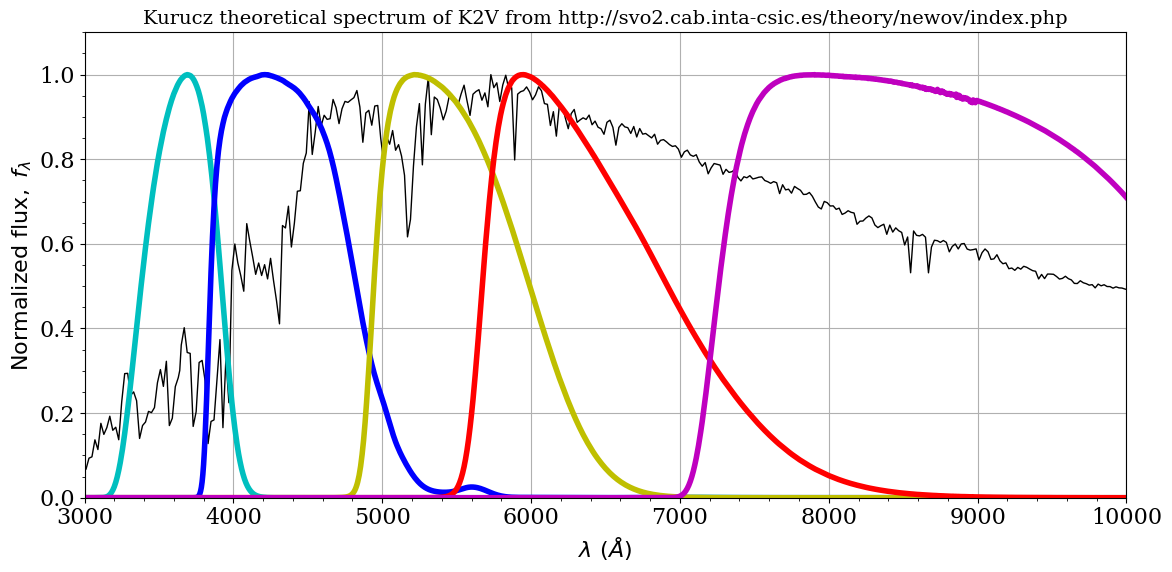

In [13]:
# plot the spectrum and response functions
fig=plt.figure()
ax=fig.gca()
fig.set_size_inches(12,6)

plt.plot(wl_theory,fl_theory,'k-',linewidth=1)    

for k in range(n_band):
    plt.plot(wl_band[k][:],sl_band[k][:],col[k],linewidth=4)

plt.xlim(wl_min,wl_max)
plt.ylim(0.,1.1)
plt.xlabel(r'$\lambda\ (\AA)$',fontsize=fsize)
plt.ylabel(r'$\mathrm{Normalized\ flux},\ f_\lambda$',fontsize=fsize)
plt.title('Kurucz theoretical spectrum of '+star+\
          ' from http://svo2.cab.inta-csic.es/theory/newov/index.php',fontsize=14)
plt.grid()
plt.minorticks_on()
plt.tight_layout()
plt.show()

In [14]:
# select a part of the spectrum that overlaps with the isolated wavelength range
fl_int = []
x_int = []
wl_int_min = min(wl_int)
wl_int_max = max(wl_int)
for i in range(n_theory):
    if wl_theory[i] >= wl_int_min and wl_theory[i] <= wl_int_max:
        x_int.append(wl_theory[i])
        fl_int.append(fl_theory[i])
        
n_fl_int = len(x_int)
print (n_int, n_fl_int)
print ("lambda_1 =", wl_int[0], ", lambda_2 =", wl_int[-1])

523 131
lambda_1 = 4670.0 , lambda_2 = 7285.0


In [15]:
# prepare to interpolate the response function at the points in which the theoretical flux is provided
sl = interpolate.interp1d(wl_int,sl_int)

# this is the integrand that represents the convolution of the flux and response function
f_int = np.linspace(0,0,n_fl_int)
for i in range(n_fl_int):
    f_int[i] = fl_int[i]*sl(x_int[i])

# Simpson's rule is used here for integration
# after the integration don't forget to multiply by the flux normalization factor 
res = fl_max*simpson(f_int, x=x_int)

### Compare the calculated bolometric corrections $BC_V$ with those listed for MS stars  in http://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt
Other bolometric corrections can be calculated as described in Appendix A of the paper
http://adsabs.harvard.edu/abs/2014MNRAS.444..392C

In [16]:
BC = 4.75-2.5*np.log10(4*sc.pi*(10*ac.pc.value)**2*ac.sigma_sb.value*Teff**4/ac.L_sun.value)+\
2.5*np.log10(res/res_0)-mA0

print ("For the star", star, "the bolometric correction in the band", band_sel, "is", BC)

For the star K2V the bolometric correction in the band V is -0.30378242974767034


# Here is what you have to do for your homework assignment

Repeat the above calculations (each time executing all cells!) until you will get 3 bolometric corrections (UBV) for all of your 4 MS stars.

Then, first prepare a table with columns showing the mass $M/M_\odot$, radius $R/R_\odot$, logarithm of luminosity $\log_{10}\,L/L_\odot$,
effective temperature $T_\mathrm{eff}$ (in K), and logarithm of gravitational acceleration $\log_{10} g$ (in g/cm$^3$), followed by columns showing the bolometric magnitude $M_\mathrm{bol}$, and your calculated bolometric corrections in U, B, and V bands.

Finally, make plots of a theoretical HRD with your 4 MS stars on it, a CMD displaying the absolute magnitudes in V versus B-V color, and a colour-colour diagram of U-B versus B-V.